In [37]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [38]:
# -----------------------------------------------------------------
# SETUP (given — don't need to rewrite this on the exam, but know it)
# -----------------------------------------------------------------
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 0 = malignant, 1 = benign
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Class balance (train):\n{y_train.value_counts(normalize=True)}\n")

Train shape: (455, 30), Test shape: (114, 30)
Class balance (train):
target
1    0.626374
0    0.373626
Name: proportion, dtype: float64



In [39]:


gnb = GaussianNB()  #Naive Beyes model
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)
score = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(f"Accuracy: {score:.2f}")
print(classification_report(y_test, y_pred))
print(cm)

# sns.heatmap(cm, annot=True)
# plt.show()


Accuracy: 0.94
              precision    recall  f1-score   support

           0       0.93      0.90      0.92        42
           1       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114

[[38  4]
 [ 3 69]]


In [40]:
ss = StandardScaler() #Feature scaling
X_train_ss = ss.fit_transform(X_train) #why did we fit transform here?
X_test_ss = ss.transform(X_test)

best_acc= 0
best_k = 0
for k in [1,3,5,7,9,11,15]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_ss,y_train)
    y_pred = knn.predict(X_test_ss)
    score = accuracy_score(y_test,y_pred)
    if (score > best_acc):
        best_acc = score
        best_k = k
print(f"{best_k} gave the best accuracy of {best_acc}")

3 gave the best accuracy of 0.9824561403508771


In [58]:


dt1 = DecisionTreeClassifier(criterion="gini", random_state=42)
dt1.fit(X_train,y_train)
y_pred1 = dt1.predict(X_test)
score1 = accuracy_score(y_test,y_pred1)
print(f"The accuracy for gini classifier is {score1}")

dt2 = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt2.fit(X_train,y_train)
y_pred2 = dt2.predict(X_test)
score2 = accuracy_score(y_test,y_pred2)
print(f"The accuracy for entropy classifier is {score2}")

feat = pd.Series(dt1.feature_importances_, index=X.columns)
print(feat.sort_values(ascending=False).head(5))

tester = DecisionTreeClassifier(max_depth= 3, random_state=42)
tester.fit(X_train,y_train)
y_pred = tester.predict(X_test)
score = accuracy_score(y_pred,y_test)
print(score)

The accuracy for gini classifier is 0.9122807017543859
The accuracy for entropy classifier is 0.9122807017543859
worst radius            0.697811
worst concave points    0.116083
worst texture           0.058881
texture error           0.052661
worst concavity         0.016325
dtype: float64
0.9385964912280702


In [57]:


rfc = RandomForestClassifier(n_estimators=100, random_state=42,oob_score=True)
rfc.fit(X_train,y_train)
y_pred = rfc.predict(X_test)
score = accuracy_score(y_pred,y_test)
print(f"The model's accuracy score is {score}")
print(f"The model's OOB score is {rfc.oob_score_}")
feat = pd.Series(rfc.feature_importances_, index = X.columns)
print(feat.sort_values(ascending= False).head(5))

The model's accuracy score is 0.956140350877193
The model's OOB score is 0.9538461538461539
worst area              0.140016
worst concave points    0.129530
worst radius            0.097696
mean concave points     0.090885
worst perimeter         0.072226
dtype: float64


In [43]:


# ada = AdaBoostClassifier(n_estimators=100, random_state=42, learning_rate=0.1)
ada = AdaBoostClassifier(n_estimators=100, random_state=42, learning_rate=1.0)
ada.fit(X_train,y_train)
y_pred = ada.predict(X_test)
score = accuracy_score(y_pred,y_test)
print(f"The model's accuracy score is {score}")
#No change in accuracy score

The model's accuracy score is 0.956140350877193


In [ ]:
dict = {
    "Naive Beyes": gnb,
    "KNN":knn,
    "Decision Tree":dt1,
    "Random Forest":rfc,
    "AdaBoost": ada
}
scores = {}

for name,model in dict.items():
    if (name == "KNN"):
        cross_score = cross_val_score(
        Pipeline([
        ("scaler", StandardScaler()),
        ("knn", model)
        ]),
        X,y,cv=5)
    else:
        cross_score = cross_val_score(model,X,y, cv=5)
    # print(f"{model}'s cross val score is {cross_score}")

    scores[name] = cross_score.mean()

feat = pd.Series(scores)

print(feat.sort_values(ascending=False).head(5))

AdaBoost         0.977162
KNN              0.961357
Random Forest    0.956094
Naive Beyes      0.938519
Decision Tree    0.917342
dtype: float64


Accuracy: 0.96
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



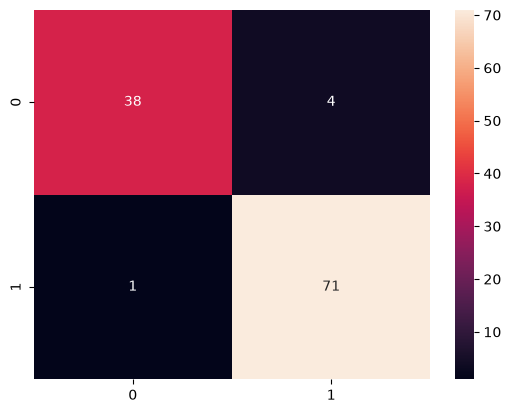

In [54]:
ada = AdaBoostClassifier(n_estimators=100, random_state=42, learning_rate=1.0)
ada.fit(X_train,y_train)
y_pred = ada.predict(X_test)
score = accuracy_score(y_pred,y_test)
cm = confusion_matrix(y_test, y_pred)
print(f"Accuracy: {score:.2f}")
print(classification_report(y_test, y_pred))

sns.heatmap(cm, annot=True)
plt.show()